In [2]:
import json
import numpy as np
import scipy as sc
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [3]:
def U(P, bias, alpha, beta, tf):
    return (alpha*P**2 + beta*P**4 - P*bias/tf)

def dU_dx(P, bias, alpha, beta, tf):
    return 2*alpha*P + 4*beta*P**3 - bias/tf

def del_U(bias, alpha, beta, tf):
    P_A = sc.optimize.fsolve(dU_dx, -1, args=(bias, alpha, beta, tf))
    P_C = sc.optimize.fsolve(dU_dx, 0, args=(bias, alpha, beta, tf))
    return abs(U(P_A, bias, alpha, beta, tf) - U(P_C, bias, alpha, beta, tf))

def Ktime_anl(bias, alpha, beta, rho, Dext_delF, tf):
    P_A = sc.optimize.fsolve(dU_dx, -1, args=(bias, alpha, beta, tf))
    P_C = sc.optimize.fsolve(dU_dx, 0, args=(bias, alpha, beta, tf))
    ddFA = 2*alpha + 12*beta*P_A**2
    ddFC = 2*alpha + 12*beta*P_C**2
    tau_k = 2*np.pi*rho/(np.sqrt(np.abs(ddFA*ddFC)))*np.exp(1/Dext_delF)
    return tau_k

# exponential model with offset: y = A * exp(B*x) + C
def expo(x, A, B, C):
    return A * np.exp(B * x) + C

def load_sr_metrics(file_path):
    """
    Load SR metrics arrays from a JSON file.
    Returns the SR metrics as numpy arrays.
    """
    with open(file_path, "r") as jf:
        data = json.load(jf)

    sd_crt = np.array(data["sd_crt"])
    bw_crt = np.array(data["bw_crt"])
    Dext_delF = np.array(data["Dext_delF"])
    Dext_delF_crt = np.array(data["Dext_delF_crt"])
    PSR = np.array(data["PSR"])
    NF = np.array(data["NF"])
    SNR = np.array(data["SNR"])
    COV = np.array(data["COV"])

    return sd_crt, bw_crt, Dext_delF, Dext_delF_crt, PSR, NF, SNR, COV

In [4]:
# Load data from JSON
with open('kt_D_results_0_A.json', 'r') as f:
    loaded_data = json.load(f)

params = loaded_data["parameters"]
results = loaded_data["results"]

# Extract parameters
alpha = params["alpha"]
beta = params["beta"]
rho = params["rho"]
tf = params["tf"]
vbias = params["vbias"]
bw = params["bw"]
Dext = np.array(params["Dext"])
delF = del_U(0, alpha, beta, tf)

# Convert results keys back to floats and get mean values
kt_D = {float(D): kt_list for D, kt_list in results.items()}
kt_mean = [np.mean(kt_D[D]) for D in sorted(kt_D.keys())]
Dext_sorted = np.array(sorted(kt_D.keys()))

In [5]:
# prepare data (uses variables loaded earlier in the notebook)
x = Dext_sorted / delF              # independent variable
y = np.array(kt_mean) * 1e3         # measured Ktime in ms
# initial guess
p0 = [ (y.max()-y.min()), -1.0, y.min() ]
popt, pcov = curve_fit(expo, x, y, p0=p0, maxfev=20000)
# smooth fit curve for plotting
x_fine = np.linspace(x.min(), x.max(), 400)
y_fit = expo(x_fine, *popt)
# horizontal lines to find intersections with
h_levels = [3.33, 5.0, 6.66]
# h_levels = [5.0]

intersections = {}
for y0 in h_levels:
    # analytic solution: exp(B*x) = (y0 - C)/A -> x = ln((y0-C)/A)/B if valid
    A,B,C = popt
    denom = A
    numer = (y0 - C)
    if denom == 0 or numer/denom <= 0 or B == 0:
        x_int = np.nan
    else:
        x_int = np.log(numer/denom) / B
    intersections[y0] = float(x_int) if np.isfinite(x_int) else np.nan

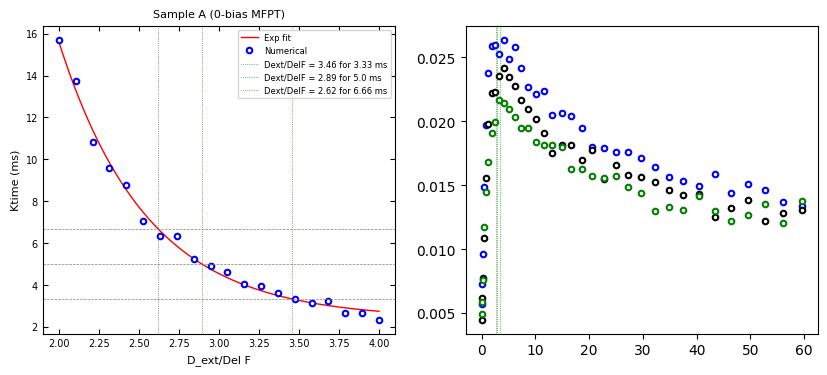

In [6]:
# Create plot
lwth = 0.5          # line width
msize = 4          # marker size
fsize = 8           # font size
m = "o"
mwth = 1.5

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Sample A (0-bias MFPT)", fontsize=fsize)
plt.xlabel("D_ext/Del F", fontsize=fsize)
plt.ylabel("Ktime (ms)", fontsize=fsize)
plt.plot(x_fine, y_fit, '-', color='red', lw=1.0, label='Exp fit') # fitted exponential
plt.plot(Dext_sorted/delF, np.array(kt_mean)*1e3, m, c="blue",  ms=msize, mew = mwth, markerfacecolor='white', label='Numerical')

# horizontal lines and intersection markers
for y0 in h_levels:
    plt.axhline(y=y0, color='gray', linestyle='--', lw=lwth)
    x_int = intersections[y0]
    plt.axvline(x=x_int, color='green', linestyle=':', lw=lwth, label=f'Dext/DelF = {x_int:.2f} for {y0} ms')

plt.tick_params(axis="both", labelsize=fsize-1)
plt.tick_params(axis="both", direction="in", top=True, right=True, labelsize=fsize-1)
plt.legend(fontsize=fsize-2)

styl = "o"
ms = 4
clr_sim = ["blue", "black", "green"]
fsig = [75, 100, 150]
plt.subplot(1, 2, 2)
for i, f in enumerate(fsig):
    file_path = f'C:\\Drive\\GITHUB\\BTP\\FE-SR\\IISc_data_analysis\\SR_simulation\\sim_rv1.{f}\\analysis\\sr_metrics_f{f}Hz_A1.575V.json'
    sd_crt, bw_crt, Dext_delF, Dext_delF_crt, PSR, NF, SNR, COV =  load_sr_metrics(f'C:\\Drive\\GITHUB\\BTP\\FE-SR\\IISc_data_analysis\\IISc_data\\sr_metrics_f{f}Hz_A1.575V.json')
    plt.plot(Dext_delF, COV, styl, linewidth = lwth, mew = mwth, markersize=ms, markerfacecolor='white', c = clr_sim[i])
    plt.axvline(x=intersections[h_levels[i]], color='green', linestyle=':', lw=lwth, label=f'Dext/DelF = {x_int:.2f} for {y0} ms')
    # plt.xlim(-0.5, 20)
plt.savefig('MFPT_Sample_A.pdf')
plt.show()

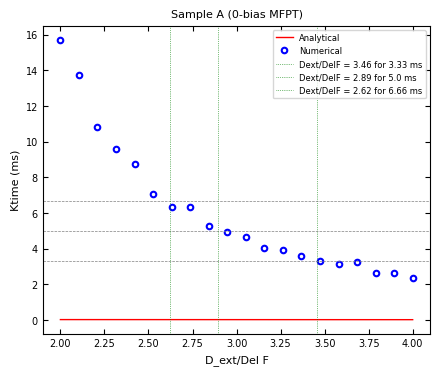

In [7]:
# Create plot
lwth = 0.5          # line width
msize = 4         # marker size
fsize = 8           # font size
m = "o"
mwth = 1.5
kt_th = Ktime_anl(0, alpha, beta, rho, x_fine, tf)
plt.figure(figsize=(5, 4))
plt.title("Sample A (0-bias MFPT)", fontsize=fsize)
plt.xlabel("D_ext/Del F", fontsize=fsize)
plt.ylabel("Ktime (ms)", fontsize=fsize)
plt.plot(x_fine, kt_th*1e3, '-', color='red', lw=1.0, label='Analytical') # fitted exponential
plt.plot(Dext_sorted/delF, np.array(kt_mean)*1e3, m, c="blue",  ms=msize, mew = mwth, markerfacecolor='white', label='Numerical')

# horizontal lines and intersection markers
for y0 in h_levels:
    plt.axhline(y=y0, color='gray', linestyle='--', lw=lwth)
    x_int = intersections[y0]
    plt.axvline(x=x_int, color='green', linestyle=':', lw=lwth, label=f'Dext/DelF = {x_int:.2f} for {y0} ms')

plt.tick_params(axis="both", labelsize=fsize-1)
plt.tick_params(axis="both", direction="in", top=True, right=True, labelsize=fsize-1)
plt.legend(fontsize=fsize-2)
plt.show()

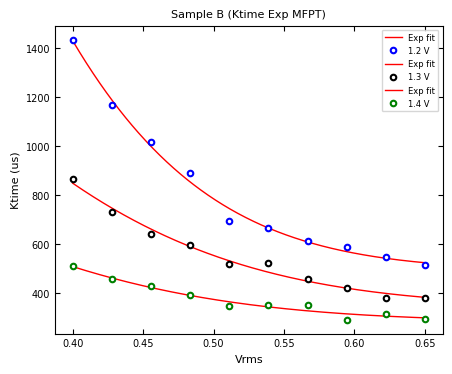

In [21]:
Vbias = [ 1.2, 1.3, 1.4]
plt.figure(figsize=(5, 4))
plt.title("Sample B (Ktime Exp MFPT)", fontsize=fsize)
plt.xlabel("Vrms", fontsize=fsize)
plt.ylabel("Ktime (us)", fontsize=fsize)
clr_sim = ["blue", "black", "green"]
for i, vbias in enumerate(Vbias):
    # Load data from JSON
    with open(f'kt_D_results_{vbias}_B_exp.json', 'r') as f:
        loaded_data = json.load(f)
    
    params = loaded_data["parameters"]
    results = loaded_data["results"]

    # Extract parameters
    alpha = params["alpha"]
    beta = params["beta"]
    rho = params["rho"]
    tf = params["tf"]
    vbias = params["vbias"]
    bw = params["bw"]
    Dext = np.array(params["Dext"])
    delF = del_U(0, alpha, beta, tf)

    # Convert results keys back to floats and get mean values
    kt_D = {float(D): kt_list for D, kt_list in results.items()}
    kt_mean = [np.mean(kt_D[D]) for D in sorted(kt_D.keys())]
    Dext_sorted = np.array(sorted(kt_D.keys()))
    # prepare data (uses variables loaded earlier in the notebook)
    x = Dext_sorted / delF              # independent variable
    y = np.array(kt_mean) * 1e6         # measured Ktime in ms
    # initial guess
    p0 = [ (y.max()-y.min()), -1.0, y.min() ]
    popt, pcov = curve_fit(expo, x, y, p0=p0, maxfev=20000)
    # smooth fit curve for plotting
    x_fine = np.linspace(x.min(), x.max(), 400)
    y_fit = expo(x_fine, *popt)


    # Create plot
    lwth = 0.5          # line width
    msize = 4          # marker size
    fsize = 8           # font size
    m = "o"
    mwth = 1.5

    plt.plot(np.sqrt(x_fine*2*rho*bw*delF)*tf, y_fit, '-', color='red', lw=1.0, label='Exp fit') # fitted exponential
    plt.plot(np.sqrt(Dext_sorted*2*rho*bw)*tf, np.array(kt_mean)*1e6, m, c=clr_sim[i],  ms=msize, mew = mwth, markerfacecolor='white', label=f'{vbias} V')

    plt.tick_params(axis="both", labelsize=fsize-1)
    plt.tick_params(axis="both", direction="in", top=True, right=True, labelsize=fsize-1)
    plt.legend(fontsize=fsize-2)

plt.show()